# Task 2, step 2: local check of the CAR training dataset

The dataset was produced by `src/run_dataset.py` with the local config `results/task2/config_local.dict` (3 train + 2 valid maps). Checks:

1. shapes and types;
2. channels;
3. comparison with a CMBpipeline map;
4. analytic vs empirical σ²;
5. spectra;
6. network forward pass;
7. time and memory for the full run.

In [1]:
import os, sys, time
import numpy as np
import healpy as hp
import torch
import matplotlib.pyplot as plt
from pixell import enmap, curvedsky, utils
from scipy.interpolate import CloughTocher2DInterpolator
from scipy.spatial import Delaunay

REPO = os.path.abspath('..')
sys.path.insert(0, os.path.join(REPO, 'src'))
os.environ['WF_CONFIG'] = os.path.join(REPO, 'results', 'task2', 'config_local.dict')
from config_loader import load_config, bin_edges
import make_dataset as dd          # CAR dataset (this repository)
import cmbpipeline_a as pa         # CMBpipeline wrappers (Task 1); pa.dd = CMBpipeline's make_dataset module
import spectrum_tools as st
import utilities, PowerSpectrum as PP, network_2d   # ../CMBpipeline/source

cfg = load_config()
FIGS = os.path.join(REPO, 'results', 'task2', 'figs'); os.makedirs(FIGS, exist_ok=True)
ARCMIN2 = utils.arcmin**2
print('config:', cfg['config_file'])
for k in ('npixels_x', 'npixels_y', 'res_arcmin', 'lmax_sim', 'fwhm_arcmin', 'DEFAULT_NOISE_LEVEL', 'nsims_train', 'nsims_valid', 'map_rescale_factor'):
    print(f'{k:22s} = {cfg[k]}')

config: /home/belen/Doctorado/ML/curvesky/polarizacion/pixell-claude/CMBpipeline-pixell/results/task2/config_local.dict
npixels_x              = 1120
npixels_y              = 320
res_arcmin             = 9.6
lmax_sim               = 1535
fwhm_arcmin            = 23.0
DEFAULT_NOISE_LEVEL    = 5e-07
nsims_train            = 3
nsims_valid            = 2
map_rescale_factor     = 0.8382


/home/belen/miniconda3/envs/torch_cmb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Shapes and types

In [2]:
X_train = torch.load(cfg['name_train'])
X_valid = torch.load(cfg['name_valid'])
print('X_train:', tuple(X_train.shape), X_train.dtype, '| X_valid:', tuple(X_valid.shape), X_valid.dtype)
ny, nx = X_train.shape[-2:]
print(f'ny = {ny} (/32 = {ny/32}), nx = {nx} (/32 = {nx/32})')
mask_car = enmap.read_map(cfg['mask_car_path'])
var_car  = enmap.read_map(cfg['variance_car_path'])
hits_car = enmap.read_map(cfg['hits_car_path'])
print('aux maps:', mask_car.shape, '| same pixels as the dataset:', mask_car.shape == (ny, nx))
print('WCS of the cut-out:', mask_car.wcs)
dec = enmap.posmap(mask_car.shape, mask_car.wcs)[0]
print(f'Dec range {np.degrees(dec.min()):.2f} ... {np.degrees(dec.max()):.2f} deg | pixel area {mask_car.pixsizemap().min()/ARCMIN2:.1f} ... {mask_car.pixsizemap().max()/ARCMIN2:.1f} arcmin2')

X_train: (3, 4, 320, 1120) torch.float32 | X_valid: (2, 4, 320, 1120) torch.float32
ny = 320 (/32 = 10.0), nx = 1120 (/32 = 35.0)
aux maps: (320, 1120) | same pixels as the dataset: True
WCS of the cut-out: car:{cdelt:[-0.16,0.16],crval:[0.08,0],crpix:[607.50,466.00]}
Dec range -74.40 ... -23.36 deg | pixel area 24.8 ... 84.6 arcmin2


## 2. Channels (0: Q_obs, 1: U_obs, 2: mask, 3: σ²)

In [3]:
X = torch.cat([X_train, X_valid]).numpy()
m = X[0, 2] > 0
out = ~m
print('mask binary:', set(np.unique(X[:, 2])) <= {0.0, 1.0}, '| observed pixels:', int(m.sum()), '| same mask in every map:', np.all(X[:, 2] == X[0, 2]))
print('Q, U, sigma2 exactly 0 outside the mask:', all(np.all(X[:, c][:, out] == 0) for c in (0, 1, 3)))
print('sigma2 > 0 inside the mask:', np.all(X[:, 3][:, m] > 0), '| same sigma2 in every map:', np.all(X[:, 3] == X[0, 3]))
print('channels equal to the aux FITS maps:', np.array_equal(X[0, 2], np.asarray(mask_car, np.float32)), np.array_equal(X[0, 3], np.asarray(var_car, np.float32)))
print('finite values:', np.isfinite(X).all())
for i in range(len(X)):
    print(f'map {i}: Q rms {X[i,0][m].std():.3f} muK, U rms {X[i,1][m].std():.3f} muK | sigma2 {X[i,3][m].min():.4f} ... {X[i,3][m].max():.4f} muK2')
cc = np.corrcoef([X[i, 0][m] for i in range(len(X))])
print('max |correlation| of Q between different maps (independent seeds):', np.abs(cc[np.triu_indices(len(X), 1)]).max().round(4))

mask binary: True | observed pixels: 286159 | same mask in every map: True
Q, U, sigma2 exactly 0 outside the mask: True
sigma2 > 0 inside the mask: True | same sigma2 in every map: True
channels equal to the aux FITS maps: True True
finite values: True
map 0: Q rms 1.484 muK, U rms 1.480 muK | sigma2 0.0459 ... 0.4399 muK2
map 1: Q rms 1.482 muK, U rms 1.480 muK | sigma2 0.0459 ... 0.4399 muK2
map 2: Q rms 1.491 muK, U rms 1.497 muK | sigma2 0.0459 ... 0.4399 muK2
map 3: Q rms 1.480 muK, U rms 1.491 muK | sigma2 0.0459 ... 0.4399 muK2
map 4: Q rms 1.489 muK, U rms 1.490 muK | sigma2 0.0459 ... 0.4399 muK2
max |correlation| of Q between different maps (independent seeds): 0.0176


## 3. A CMBpipeline map for comparison

One map made with CMBpipeline's own functions, SO "rect", with the same spectra, beam and noise model:
- `make_dataset.get_inhomogenous_noise('rect', …)`;
- `make_inho_maps_pln` (synfast, `hp.smoothing`, ψ rotation, equidistant projection, Clough–Tocher).

CMBpipeline's channel 3 comes from `make_variance_map.py`, the pixel variance of projected noise realizations. That file is not available locally, so it is rebuilt here with the same steps from 30 realizations.

In [4]:
geo = pa.so_geometry(cfg['nside'], 704, 416, 8, cfg['so_hits_path'])
import projections as pj
_, nhits_hp, *_ = pj.sph_mask(nside=cfg['nside'], so_hits_file=cfg['so_hits_path']).make_SO_mask()
mk = pa.dd.make_dataset(1, 1, 1, True, False, nbins=704, nside=cfg['nside'], fwhm=cfg['fwhm_arcmin'],
                        DEFAULT_NOISE_LEVEL=cfg['DEFAULT_NOISE_LEVEL'])
_, variance_hp = mk.get_inhomogenous_noise('rect', geo['mask'], nhits=nhits_hp)        # sigma^2 per HEALPix pixel

np.random.seed(7)                                                                       # CMBpipeline draws from the global state
t0 = time.time()
Q_pln, U_pln, mask2d = mk.make_inho_maps_pln(variance_hp, geo['proj'], geo['valid_index'], geo['mask'],
                                             geo['z_eq'], geo['psi'], 'rect', mask2d=geo['mask2d'])
print(f'CMBpipeline map in {time.time()-t0:.1f} s: shape {Q_pln.shape}, observed plane pixels {int(mask2d.sum())}')

# channel 3 of CMBpipeline: variance of projected noise-only maps (make_variance_map.py, here 30 realizations)
tri = Delaunay(geo['z_eq'])
noise_pln = []
for i in range(30):
    n = utilities.sigma2_to_map(variance_hp, geo['mask'], np.random.default_rng(500 + i))
    g = CloughTocher2DInterpolator(tri, (geo['mask'] * n)[geo['valid_index']], fill_value=0)(geo['grid_x'], geo['grid_y'])
    g[mask2d == 0] = 0; noise_pln.append(g)
var_pln = np.var(noise_pln, axis=0)
m2 = mask2d > 0
print(f'CMBpipeline map: Q rms {Q_pln[m2].std():.3f} muK, U rms {U_pln[m2].std():.3f} muK | sigma2_pln {var_pln[m2].min():.4f} ... {var_pln[m2].max():.4f} muK2')

CMBpipeline map in 14.1 s: shape (416, 704), observed plane pixels 189097
CMBpipeline map: Q rms 1.486 muK, U rms 1.479 muK | sigma2_pln 0.0000 ... 27.0077 muK2


CMBpipeline map: Q rms 1.485 muK, U rms 1.481 muK | sigma2_pln 0.0000 ... 27.0077 muK2


In [5]:
# noise level per steradian N = sigma^2 x pixel solid angle, at the same sky positions
omega_hp = hp.nside2pixarea(cfg['nside'])
N_hp = variance_hp * omega_hp                                    # CMBpipeline on HEALPix
N_car = np.asarray(var_car) * np.asarray(mask_car.pixsizemap())  # CAR dataset
N_hp_at_car = np.asarray(dd.make_dataset(0, 0, 0, True, False).healpix_to_car(N_hp, mask_car.shape, mask_car.wcs))
print(f'CAR vs CMBpipeline HEALPix, N at the same position: max |N_car / N_hp - 1| = {np.abs(N_car[m] / N_hp_at_car[m] - 1).max():.1e}')
jac = np.sin(np.hypot(geo['grid_x'], geo['grid_y'])) / np.hypot(geo['grid_x'], geo['grid_y'])
N_pln = var_pln * geo['pix']**2 * jac                             # plane pixel: true solid angle
print(f"{'':30s}{'mean N [muK2 sr]':>18s}{'= muK-arcmin':>14s}")
for name, N, w in (('HEALPix (CMBpipeline sphere)', N_hp[geo['mask'] > 0], None), ('CAR dataset (area weighted)', N_car[m], np.asarray(mask_car.pixsizemap())[m]),
                   ('CMBpipeline plane (after interp.)', N_pln[m2], None)):
    mu = np.average(N, weights=w)
    print(f'{name:30s}{mu:18.3e}{np.sqrt(mu)/utils.arcmin:14.2f}')

CAR vs CMBpipeline HEALPix, N at the same position: max |N_car / N_hp - 1| = 8.4e-08
                                mean N [muK2 sr]  = muK-arcmin
HEALPix (CMBpipeline sphere)           5.000e-07          2.43
CAR dataset (area weighted)            5.000e-07          2.43
CMBpipeline plane (after interp.)         6.694e-07          2.81


**Reading.**
- The CAR noise has exactly CMBpipeline's noise level per steradian at every position, on the sphere (N = 5×10⁻⁷ μK² sr = 2.43 μK-arcmin).
- The interpolated plane noise is *correlated* between neighbouring pixels, so σ²_pln × pixel area is not a white-noise level. The larger value above only reflects the resampling.
- CMBpipeline's σ² channel also has edge artifacts from the interpolation, counted below.

In [6]:
from scipy.ndimage import distance_transform_edt
d_edge = distance_transform_edt(m2)                     # plane pixels to the mask2d edge
print(f'CMBpipeline sigma2_pln inside mask2d: median {np.median(var_pln[m2]):.4f} muK2, 99.9 % {np.percentile(var_pln[m2], 99.9):.4f}, max {var_pln[m2].max():.2f}')
print(f'  pixels with sigma2 = 0 (in mask2d but outside the triangulation: griddata fill 0): {(var_pln[m2] == 0).sum()}, '
      f'all within 2 px of the edge: {np.all(d_edge[m2 & (var_pln == 0)] <= 2)}')
print(f'  pixels with sigma2 > 1 muK2 (Clough-Tocher overshoot): {(var_pln[m2] > 1).sum()}, all within 2 px of the edge: {np.all(d_edge[m2 & (var_pln > 1)] <= 2)}')
print(f'  Q_pln = 0 inside mask2d at {(Q_pln[m2] == 0).sum()} pixels')
print(f'CAR dataset sigma2 inside the mask: min {X[0, 3][m].min():.4f}, max {X[0, 3][m].max():.4f} muK2 (smooth: 1/hits x 1/pixel area), no zeros')

CMBpipeline sigma2_pln inside mask2d: median 0.0785 muK2, 99.9 % 0.3834, max 27.01
  pixels with sigma2 = 0 (in mask2d but outside the triangulation: griddata fill 0): 129, all within 2 px of the edge: True
  pixels with sigma2 > 1 muK2 (Clough-Tocher overshoot): 17, all within 2 px of the edge: True
  Q_pln = 0 inside mask2d at 129 pixels
CAR dataset sigma2 inside the mask: min 0.0459, max 0.4399 muK2 (smooth: 1/hits x 1/pixel area), no zeros


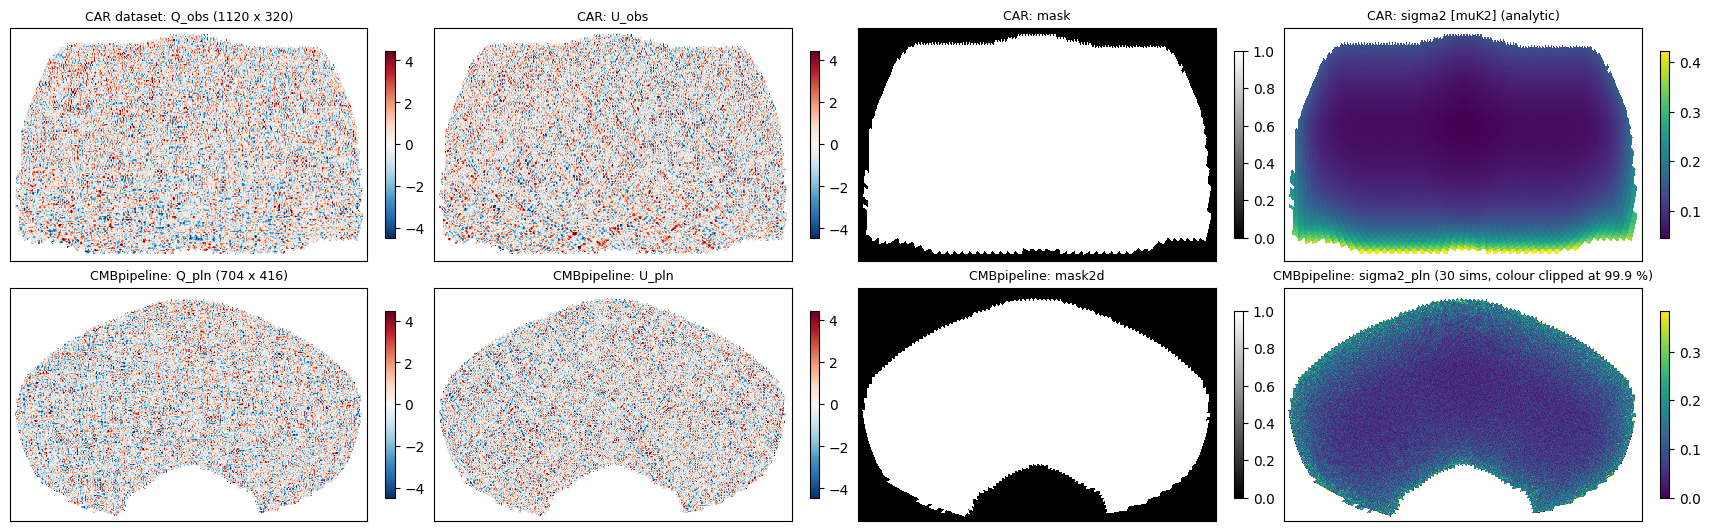

In [7]:
v = lambda a, mm: 3 * np.std(np.asarray(a)[mm])
fig, ax = plt.subplots(2, 4, figsize=(17, 5.2), constrained_layout=True)
def im(a, arr, mm, title, cmap='RdBu_r', sym=True):
    arr = np.array(arr, float); arr[~mm] = np.nan
    lim = v(arr, mm)
    h = a.imshow(arr, origin='lower', cmap=cmap, vmin=-lim if sym else np.nanmin(arr), vmax=lim if sym else np.nanpercentile(arr, 99.9), aspect='auto', interpolation='nearest')
    a.set_title(title, fontsize=9); a.set_xticks([]); a.set_yticks([]); plt.colorbar(h, ax=a, shrink=0.8)
im(ax[0, 0], X[0, 0], m, f'CAR dataset: Q_obs ({nx} x {ny})'); im(ax[0, 1], X[0, 1], m, 'CAR: U_obs')
im(ax[0, 2], X[0, 2], np.ones_like(m), 'CAR: mask', 'gray', False); im(ax[0, 3], X[0, 3], m, 'CAR: sigma2 [muK2] (analytic)', 'viridis', False)
im(ax[1, 0], Q_pln, m2, 'CMBpipeline: Q_pln (704 x 416)'); im(ax[1, 1], U_pln, m2, 'CMBpipeline: U_pln')
im(ax[1, 2], mask2d, np.ones_like(m2), 'CMBpipeline: mask2d', 'gray', False); im(ax[1, 3], var_pln, m2, 'CMBpipeline: sigma2_pln (30 sims, colour clipped at 99.9 %)', 'viridis', False)
plt.savefig(f'{FIGS}/channels.png', dpi=130); plt.show()

## 4. Analytic σ² vs the variance of 100 noise realizations

The noise is drawn per CAR pixel with the analytic σ², so the empirical pixel variance should scatter around it by √(2/99) ≈ 0.14.

In [8]:
gen = dd.make_dataset(0, 0, 0, True, False)
noise = np.array([gen.get_inho_noise(var_car, mask_car, np.random.default_rng(900 + i)) for i in range(100)])
ratio = noise[:, m].var(axis=0, ddof=1) / np.asarray(var_car)[m]
print(f'empirical / analytic sigma2: mean {ratio.mean():.4f}, std {ratio.std():.4f} (expected {np.sqrt(2/99):.4f}), '
      f'mean over pixels of the empirical / mean analytic {noise[:, m].var(axis=0, ddof=1).mean() / np.asarray(var_car)[m].mean():.4f}')

empirical / analytic sigma2: mean 1.0000, std 0.1420 (expected 0.1421), mean over pixels of the empirical / mean analytic 1.0002


## 5. Spectra: CAR maps (curved sky on the cut-out) vs theory, and the CMBpipeline map (its flat estimator)

- **CAR:** `map2alm(method='2d')` of the masked Q/U on the cut-out, then `alm2cl` / w₂.
- **CMBpipeline:** the flat E/B of the plane map (`transf_eb2_np`), then `PowerSpectrum.power` binned in ℓ = |k|, / w₂.
- **Expected:** C_ℓB_ℓ² + N, with N = the w₂-weighted mean noise level. EE is signal-dominated; BB is noise- and leakage-dominated (Task 1).

np.float64(5.000391962301391e-07)

noise level: CAR N_eff = 5.000e-07, CMBpipeline plane N_eff = 6.694e-07 muK2 sr
       bin  EE CAR/exp  EE CMBp/exp  BB CAR/exp  BB CMBp/exp
   4-24          0.619        0.258      22.337        7.415
  24-44          0.943        0.884       3.263        3.901
  44-64          0.941        1.088       3.062        3.046
  64-84          0.887        0.924       2.845        3.333
  84-104         0.904        0.862       2.740        2.805
 104-125         0.840        0.866       2.666        2.735
 125-150         0.849        0.885       2.301        2.274
 150-180         0.788        0.805       1.763        1.914
 180-216         0.756        0.772       1.390        1.396
 216-259         0.631        0.708       1.162        1.375
 259-311         0.507        0.529       1.107        1.385
 311-373         0.378        0.389       1.051        1.336
 373-447         0.265        0.245       0.832        0.973
 447-537         0.162        0.145       0.563        0.623
 537-

ValueError: operands could not be broadcast together with shapes (18,) (1536,) 

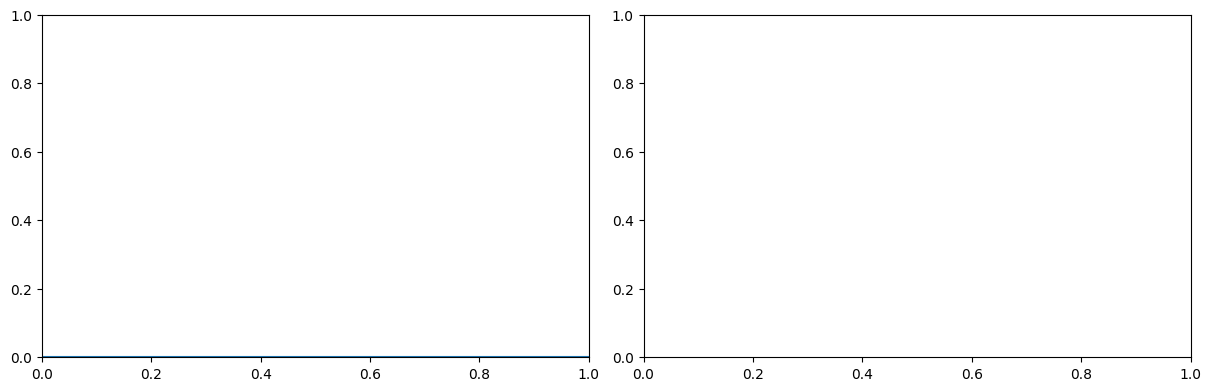

In [14]:
bins = bin_edges(cfg); lb = 0.5 * (bins[1:] + bins[:-1])
cltt, clee, clbb = np.load(cfg['spectra_path'])
bl2 = hp.gauss_beam(cfg['fwhm_rad'], lmax=cfg['lmax_sim'])**2
w2_car = np.sum(np.asarray(mask_car)**2 * mask_car.pixsizemap()) / (4 * np.pi)
N_eff_car = np.sum(np.asarray(mask_car)**2 * N_car * mask_car.pixsizemap()) / np.sum(np.asarray(mask_car)**2 * mask_car.pixsizemap())
lmax_car = int(round(np.pi / (cfg['res_arcmin'] * utils.arcmin))) - 1       # 1124: fejer1 exactness at 9.6'
cl_car = []
for i in range(len(X)):
    qu = enmap.enmap(X[i, :2].astype(np.float64), mask_car.wcs)
    a = curvedsky.map2alm(qu, lmax=lmax_car, spin=2, method='2d')          # already masked (channels 0-1)
    cl_car.append([st.bin_cl(curvedsky.alm2cl(a[j]), bins) / w2_car for j in (0, 1)])
cl_car = np.array(cl_car)

ps_A = PP.PowerSpectrum(cfg['nside'], 704, 416, geo['dx'], geo['dy'], cfg['fwhm_arcmin'], len(bins) - 1, bins, 1.0, cfg['DEFAULT_NOISE_LEVEL'])
ell_flat, _ = ps_A.flat_spectrum_xy(clee)
E_pln, B_pln = pa.plane_eb(Q_pln, U_pln, 704, 416, geo['dx'], geo['dy'])
w2_pln = np.mean(mask2d**2)
cl_pln = np.array([st.flat_spectrum_A(ps_A, M, ell_flat, bins, w2_pln) for M in (E_pln, B_pln)])
N_eff_pln = np.mean(N_pln[m2])

th = {j: st.bin_cl((clee if j == 0 else clbb)[:cfg['lmax_sim'] + 1], bins) for j in (0, 1)}
print(f'noise level: CAR N_eff = {N_eff_car:.3e}, CMBpipeline plane N_eff = {N_eff_pln:.3e} muK2 sr')
print(f"{'bin':>10s}{'EE CAR/exp':>12s}{'EE CMBp/exp':>13s}{'BB CAR/exp':>12s}{'BB CMBp/exp':>13s}")
for i in range(len(lb)):
    print(f'{bins[i]:4d}-{bins[i+1]:<5d}{cl_car[:, 0, i].mean() / (th[0][i] + N_eff_car):12.3f}{cl_pln[0, i] / (th[0][i] + N_eff_pln):13.3f}'
          f'{cl_car[:, 1, i].mean() / (th[1][i] + N_eff_car):12.3f}{cl_pln[1, i] / (th[1][i] + N_eff_pln):13.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
for j, name in ((0, 'EE'), (1, 'BB')):
    ax[j].axhline(y=N_eff_car)
    ax[j].plot(lb, th[j]*bl2, 'k-', label='theory C_l B_l^2 ')
    ax[j].plot(lb, th[j], 'k:', lw=1, label='theory C_l B_l^2')
    ax[j].plot(lb, cl_car[:, j].mean(0), 'o-', color='#1baf7a', ms=3, label=f'CAR dataset (mean of {len(X)}, curved sky)')
    ax[j].plot(lb, cl_pln[j], 's-', color='#2a78d6', ms=3, label='CMBpipeline map (flat)')
    ax[j].set_yscale('log'); ax[j].set_xlabel('ell'); ax[j].set_title(name); ax[j].legend(fontsize=8)
plt.savefig(f'{FIGS}/spectra.png', dpi=130); plt.show()

## 6. Network: forward pass with the training normalization

In [10]:
# normalization of training_opt_beam_changed.create_dataloader (noise_type = 'inho')
factor = cfg['map_rescale_factor']
def normalize(batch):
    q, u, mk_, inho = batch[:, 0:1], batch[:, 1:2], batch[:, 2:3], batch[:, 3:4]
    qn = (q - q.mean(dim=(2, 3), keepdim=True)) * factor
    un = (u - u.mean(dim=(2, 3), keepdim=True)) * factor
    return torch.cat((qn, un, mk_, inho), dim=1)

torch.manual_seed(0)
model = network_2d.DeepWiener_threechannels(2, 2, filters=[8, 16, 24, 32, 32, 32]).eval()   # untrained, small filters
for name, batch in (('CAR dataset', X_train[:1]),
                    ('CMBpipeline', torch.from_numpy(np.stack([Q_pln, U_pln, mask2d, var_pln])[None].astype(np.float32)))):
    xin = normalize(batch)
    t0 = time.time()
    with torch.no_grad():
        yout = model(xin)
    print(f'{name:12s}: input {tuple(xin.shape)} -> output {tuple(yout.shape)} ({time.time()-t0:.2f} s, CPU) | '
          f'normalized Q rms in mask {xin[0, 0][xin[0, 2] > 0].std():.3f}, sigma2 channel max {xin[0, 3].max():.3f}')

CAR dataset : input (1, 4, 320, 1120) -> output (1, 2, 320, 1120) (0.35 s, CPU) | normalized Q rms in mask 1.244, sigma2 channel max 0.440


CMBpipeline : input (1, 4, 416, 704) -> output (1, 2, 416, 704) (0.26 s, CPU) | normalized Q rms in mask 1.245, sigma2 channel max 27.008


## 7. Time and memory for the full run

In [11]:
gen = dd.make_dataset(0, 0, 0, True, False)
ps = gen._create_spectrum_array(cltt, clee, clbb)
t0 = time.time()
for i in range(5):
    gen.make_inho_maps_car(ps, var_car, mask_car, mask_car.shape, mask_car.wcs, 10 + i, 20 + i)
tmap = (time.time() - t0) / 5
nmaps = cfg['nsims_train'] if cfg['nsims_train'] > 10 else 1000
print(f'time per map: {tmap:.2f} s  ->  1100 maps: {1100 * tmap / 60:.1f} min (single process)')
print(f'X_train (1000, 4, {ny}, {nx}) float32: {1000*4*ny*nx*4/1e9:.2f} GB | X_valid (100, ...): {100*4*ny*nx*4/1e9:.2f} GB '
      f'| CMBpipeline (1000, 4, 416, 704): {1000*4*416*704*4/1e9:.2f} GB')

time per map: 0.31 s  ->  1100 maps: 5.7 min (single process)
X_train (1000, 4, 320, 1120) float32: 5.73 GB | X_valid (100, ...): 0.57 GB | CMBpipeline (1000, 4, 416, 704): 4.69 GB
